In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

In [2]:
spark = SparkSession.builder \
    .appName("FCO Preisvergleich") \
    .config("spark.master", "local[*]") \
    .getOrCreate()

In [13]:
df_kayak = spark.read.option("header", True).option("inferSchema", True).csv("Kafka_Spark/CSVs/kayak_durchschnittspreise_fco.csv")
df_momondo = spark.read.option("header", True).option("inferSchema", True).csv("Kafka_Spark/CSVs/momondo_durchschnittspreise_fco.csv")
df_amadeus = spark.read.option("header", True).option("inferSchema", True).csv("Kafka_Spark/CSVs/amadeus_durchschnittspreise_fco.csv")


In [10]:
df_gesamt = df_kayak.unionByName(df_momondo).unionByName(df_amadeus)

# Umwandlung für Plot mit Pandas
df_gesamt_pd = df_gesamt.toPandas()
df_pivot = df_gesamt_pd.pivot(index='Abflug', columns='Quelle', values='Durchschnittspreis')

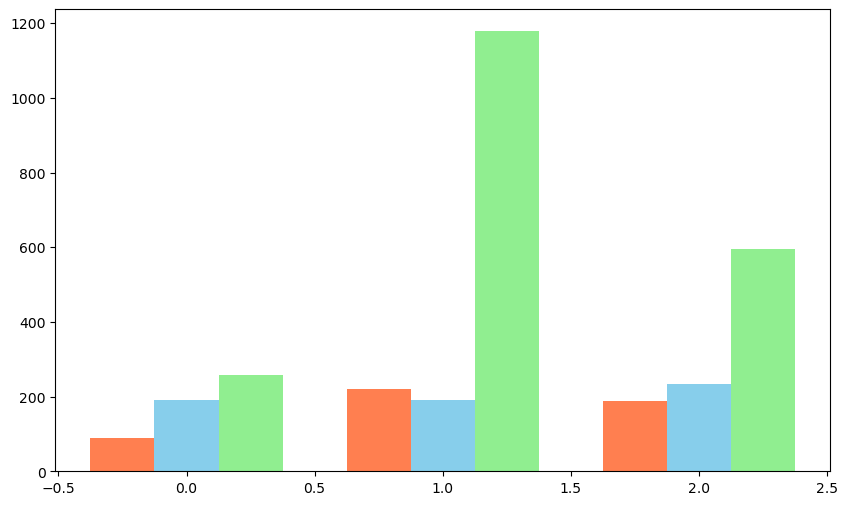

In [11]:
df_pivot = df_pivot.dropna()  
x = np.arange(len(df_pivot.index))
width = 0.25

plt.figure(figsize=(10, 6))
bars_k = plt.bar(x - width, df_pivot['Kayak'], width=width, label='Kayak', color='coral')
bars_m = plt.bar(x, df_pivot['Momondo'], width=width, label='Momondo', color='skyblue')
bars_a = plt.bar(x + width, df_pivot['Amadeus'], width=width, label='Amadeus API', color='lightgreen')


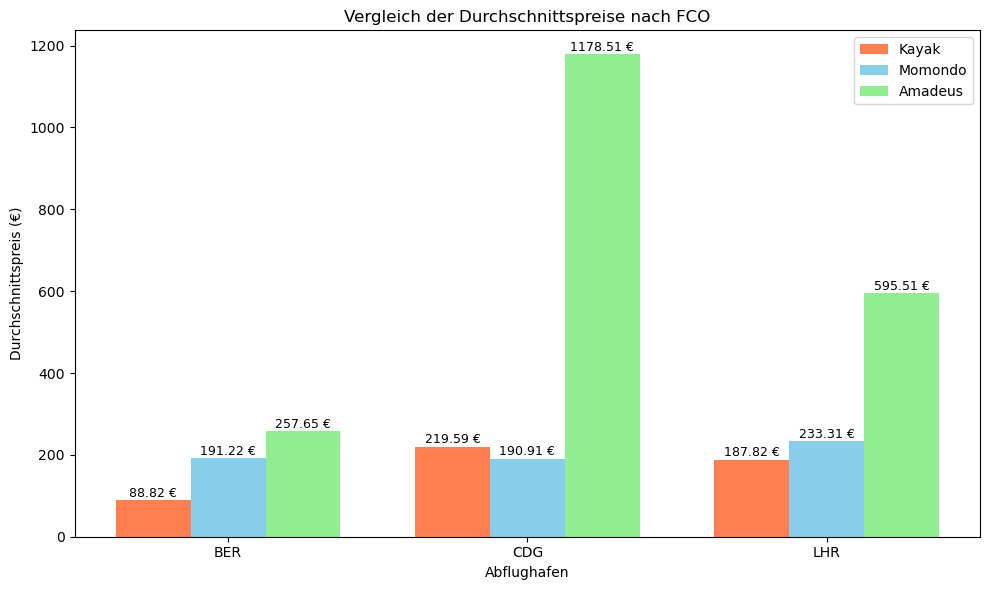

In [12]:
df_pivot = df_pivot.dropna()  # oder .fillna(0)

x = np.arange(len(df_pivot.index))
width = 0.25

plt.figure(figsize=(10, 6))
bars_k = plt.bar(x - width, df_pivot['Kayak'], width=width, label='Kayak', color='coral')
bars_m = plt.bar(x, df_pivot['Momondo'], width=width, label='Momondo', color='skyblue')
bars_a = plt.bar(x + width, df_pivot['Amadeus'], width=width, label='Amadeus', color='lightgreen')

for bars in [bars_k, bars_m, bars_a]:
    for bar in bars:
        height = bar.get_height()
        if np.isfinite(height):  # Sicher gegen kaputte Werte
            plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.2f} €",
                     ha='center', va='bottom', fontsize=9)

plt.xlabel("Abflughafen")
plt.ylabel("Durchschnittspreis (€)")
plt.title("Vergleich der Durchschnittspreise nach FCO")
plt.xticks(x, df_pivot.index)
plt.legend()
plt.tight_layout()

os.makedirs("Pictures", exist_ok=True)
plt.savefig("Pictures/durchschnittspreise_fco_vergleich.png", dpi=300)
plt.show()